# Parameter-matching: the parameterised-Gaussian toy

We reuse the elliptic-PDE training of a scalar potential $\phi(x, \theta)$,

$$\mathcal{L}(\phi) = \mathbb{E}_{p_\theta(x),\,p(\theta)}\Bigl[\bigl(\partial_\theta \log p_\theta(x) + \Delta_x\phi + \nabla_x\phi\cdot\nabla_x\log p_\theta(x)\bigr)^2\Bigr],$$

but on `nami_toys.ParameterisedGaussian` instead of the 1d analytic tilt.  This is a
**2-d signal+background mixture**

$$p_\theta(x) = f\,\mathcal{N}\!\bigl(x;\,\mu_\mathrm{sig}(\theta),\,\Sigma_\mathrm{sig}\bigr) + (1-f)\,\mathcal{N}\!\bigl(x;\,\mu_\mathrm{bkg},\,\Sigma_\mathrm{bkg}\bigr),$$

whose signal mean moves with a **scalar** $\theta$ along `param_dim` while the background
stays fixed.  Because $\theta$ is one-dimensional this is the standard
`parameter_flow_loss` (one scalar potential, no Frobenius compatibility), only now the
event space is 2-d.

The mixture log-density is differentiable, so **both scores come straight from autograd** —
no closed-form algebra needed:

$$\nabla_x \log p_\theta(x) = \partial_x\log p_\theta,\qquad \partial_\theta\log p_\theta(x) = \partial_\theta\log p_\theta.$$

We check three things, exactly as in the 1d notebook:

1. training drives the PDE residual down;
2. `ParameterFlow.transport` carries samples $p_{\theta_0}\to p_{\theta_1}$ (2-d scatter + marginals);
3. `score_supply` inverts the PDE back to the joint score.

In [35]:
import matplotlib.pyplot as plt
plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pitayasmoothie-dark.mplstyle')
import torch

from nami import (
    RK4,
    LinearParameterPath,
    OracleScore,
    ParameterFlow,
    ScalarPotentialField,
    parameter_flow_loss,
)
from nami_toys import ParameterisedGaussian

torch.manual_seed(7)
generator = torch.Generator().manual_seed(7)

## The toy and its autograd scores

`ParameterisedGaussian()` uses the package defaults: a 2-d signal with correlated
covariance, a wider fixed background, signal fraction $f=0.3$, and `param_dim=0`
(so $\mu_\mathrm{sig}(\theta) = (\theta, 0)$).

The toy ships a `log_prob(x, theta)` that only accepts a *float* `theta`.  For training
we need a version that is **batched over `theta` and differentiable w.r.t. both `x` and
`theta`**, so we rebuild the mixture density with a broadcast mean and read off the scores
with `torch.autograd.grad`.  The score callables must re-enable grad internally because
`parameter_flow_loss` evaluates its frozen targets under `torch.no_grad()`.

In [36]:
toy = ParameterisedGaussian()  # 2-d, param_dim=0, sig_frac=0.3, package-default cov
d = toy.d
pdim = toy.param_dim


def log_prob_batched(x, theta):
    """x: (*lead, d), theta: (*lead, 1) -> (*lead,) mixture log p(x|theta), autograd-friendly."""
    mu_sig = toy.sig_loc.to(x).expand(*theta.shape[:-1], d).clone()
    idx = (*([slice(None)] * (mu_sig.dim() - 1)), pdim)
    mu_sig[idx] = theta[..., 0]  # signal mean tracks theta along param_dim
    sig = torch.distributions.MultivariateNormal(mu_sig, toy.sig_cov.to(x))
    bkg = torch.distributions.MultivariateNormal(toy.bkg_loc.to(x), toy.bkg_cov.to(x))
    p = (
        toy.sig_frac * sig.log_prob(x).exp()
        + (1 - toy.sig_frac) * bkg.log_prob(x).exp()
    )
    return p.clamp_min(1e-30).log()


def spatial_score_fn(x, theta):
    with torch.enable_grad():  # called under no_grad inside the loss
        x = x.detach().requires_grad_(True)
        lp = log_prob_batched(x, theta)
        (g,) = torch.autograd.grad(lp.sum(), x)
    return g  # (*lead, d)


def joint_score_fn(x, theta):
    with torch.enable_grad():
        theta = theta.detach().requires_grad_(True)
        lp = log_prob_batched(x, theta)
        (g,) = torch.autograd.grad(lp.sum(), theta)
    return g  # (*lead, 1)


def sample_p_theta(theta_col, generator):
    """theta_col: (N, 1) -> x: (N, d), one mixture draw per theta (reparameterised)."""
    n = theta_col.shape[0]
    is_sig = torch.rand(n, generator=generator) < toy.sig_frac
    mu_sig = toy.sig_loc.expand(n, d).clone()
    mu_sig[:, pdim] = theta_col[:, 0]
    l_sig = torch.linalg.cholesky(toy.sig_cov)
    l_bkg = torch.linalg.cholesky(toy.bkg_cov)
    eps = torch.randn(n, d, generator=generator)
    xs = mu_sig + eps @ l_sig.T
    xb = toy.bkg_loc + eps @ l_bkg.T
    return torch.where(is_sig.unsqueeze(-1), xs, xb)


joint = OracleScore(joint_score_fn)
spatial = OracleScore(spatial_score_fn)

# shape sanity
_th = torch.rand(5, 1)
_x = sample_p_theta(_th, generator)
print('x', tuple(_x.shape), 'spatial', tuple(spatial(_x, _th).shape), 'joint', tuple(joint(_x, _th).shape))

x (5, 2) spatial (5, 2) joint (5, 1)


Let's look at the family we are about to match: the signal blob slides along $x_0$ with
$\theta$ while the broad background stays put.

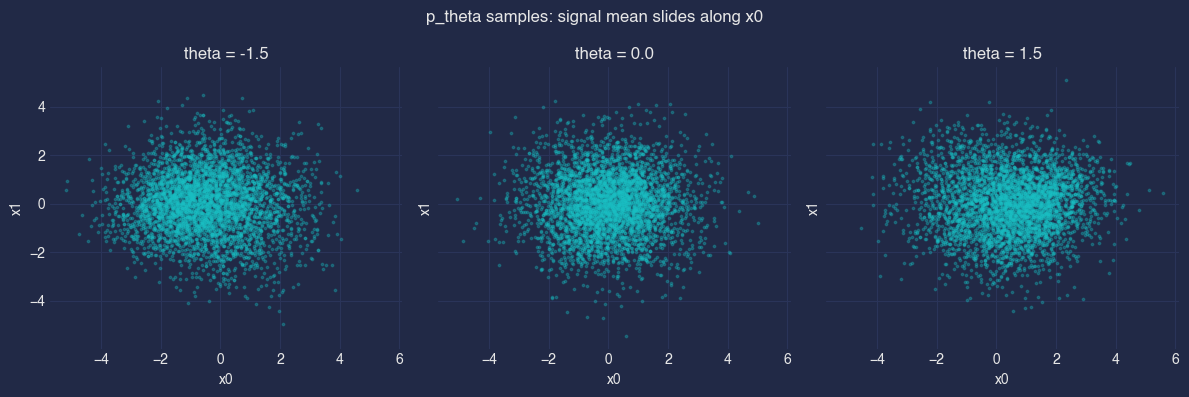

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)
for ax, th in zip(axes, (-1.5, 0.0, 1.5)):
    pts = sample_p_theta(torch.full((4000, 1), th), generator)
    ax.scatter(pts[:, 0], pts[:, 1], s=3, alpha=0.3)
    ax.set_title(f'theta = {th}')
    ax.set_xlabel('x0'); ax.set_ylabel('x1')
fig.suptitle('p_theta samples: signal mean slides along x0')
plt.tight_layout(); plt.show()

## Train $\phi$ on the PDE residual

Sample $\theta \sim \mathcal{U}(-2, 2)$, draw $x\sim p_\theta$, and minimise the elliptic
residual.  A cosine schedule mirrors the 1d run.

step 0: loss 1.327e-01
step 500: loss 2.984e-04
step 1000: loss 1.057e-04
step 1500: loss 2.765e-05
step 2000: loss 1.526e-05
step 2500: loss 1.509e-05


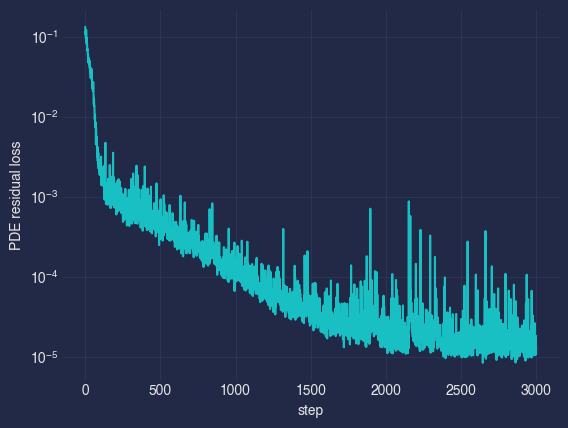

In [38]:
field = ScalarPotentialField(d, theta_dim=1, hidden=64, layers=3)

optimizer = torch.optim.Adam(field.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=3000)
theta_lo, theta_hi = -2.0, 2.0
losses = []
for step in range(3000):
    theta = torch.rand(512, 1, generator=generator) * (theta_hi - theta_lo) + theta_lo
    x = sample_p_theta(theta, generator)
    loss = parameter_flow_loss(
        field, x=x, theta=theta, joint_score=joint, spatial_score=spatial
    )
    optimizer.zero_grad(); loss.backward(); optimizer.step(); scheduler.step()
    losses.append(loss.item())
    if step % 500 == 0:
        print(f'step {step}: loss {loss.item():.3e}')

plt.semilogy(losses)
plt.xlabel('step'); plt.ylabel('PDE residual loss'); plt.show()

## Held-out PDE residual across $\theta$

The 1d toy had a closed-form continuity velocity to compare $\nabla_x\phi$ against.  Here
the mixture makes $\phi$ non-analytic, so there is no elementary 2-d velocity to diff
against — instead we probe generalisation with the quantity we actually trained: the
elliptic-PDE residual

$$r(x;\theta) = \partial_\theta\log p_\theta + \Delta_x\phi + \nabla_x\phi\cdot\nabla_x\log p_\theta.$$

We evaluate its RMS on *fresh* $p_\theta$ draws over a $\theta$ grid that extends **beyond**
the training band $[-2, 2]$.  Inside the band the residual should sit near the converged
loss; outside it we expect graceful degradation (the network never saw those $\theta$).
We reuse `parameter_flow_loss(..., reduction='none')` so the residual is exactly the
trained objective, not a re-derivation.

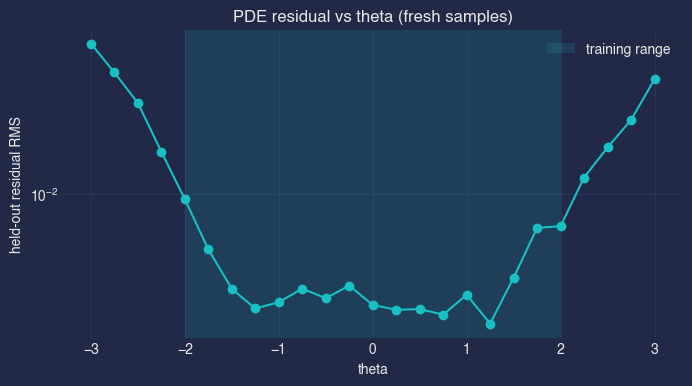

In [39]:
grid_theta = torch.linspace(-3.0, 3.0, 25)
rms_by_theta = []
for tval in grid_theta:
    theta = torch.full((4096, 1), tval.item())
    x = sample_p_theta(theta, generator)
    res = parameter_flow_loss(
        field, x=x, theta=theta, joint_score=joint, spatial_score=spatial,
        reduction='none', create_graph=False,
    )
    rms_by_theta.append(res.mean().sqrt().item())

plt.figure(figsize=(8, 4))
plt.axvspan(theta_lo, theta_hi, alpha=0.15, label='training range')
plt.semilogy(grid_theta.numpy(), rms_by_theta, marker='o')
plt.xlabel('theta'); plt.ylabel('held-out residual RMS')
plt.title('PDE residual vs theta (fresh samples)'); plt.legend(); plt.show()

## Transport $p_{\theta_0} \to p_{\theta_1}$

Bind a `LinearParameterPath` and integrate

$$\dot x = \dot\theta(s)\,\nabla_x\phi\bigl(x, \theta(s)\bigr).$$

Transporting samples drawn at $\theta_0$ should reproduce a fresh draw at $\theta_1$.
Note the mixture only moves the signal (a fraction $f$ of the mass), so the overall mean
shift along $x_0$ is $f\,(\theta_1-\theta_0)$ — the background component is carried but its
mean is unchanged.

In [40]:
theta_0, theta_1 = -1.0, 1.0
process = ParameterFlow(field, RK4(steps=64))(
    LinearParameterPath(torch.tensor([theta_0]), torch.tensor([theta_1]))
)

x0 = sample_p_theta(torch.full((8000, 1), theta_0), generator)
with torch.no_grad():
    x1 = process.transport(x0)
x1_true = sample_p_theta(torch.full((8000, 1), theta_1), generator)

print('start    mean :', [f'{v:+.3f}' for v in x0.mean(0).tolist()])
print('transported  :', [f'{v:+.3f}' for v in x1.mean(0).tolist()])
print('true target  :', [f'{v:+.3f}' for v in x1_true.mean(0).tolist()])
print('expected dx0 :', f'{toy.sig_frac * (theta_1 - theta_0):+.3f}')

start    mean : ['-0.315', '-0.018']
transported  : ['+0.282', '-0.018']
true target  : ['+0.292', '-0.022']
expected dx0 : +0.600


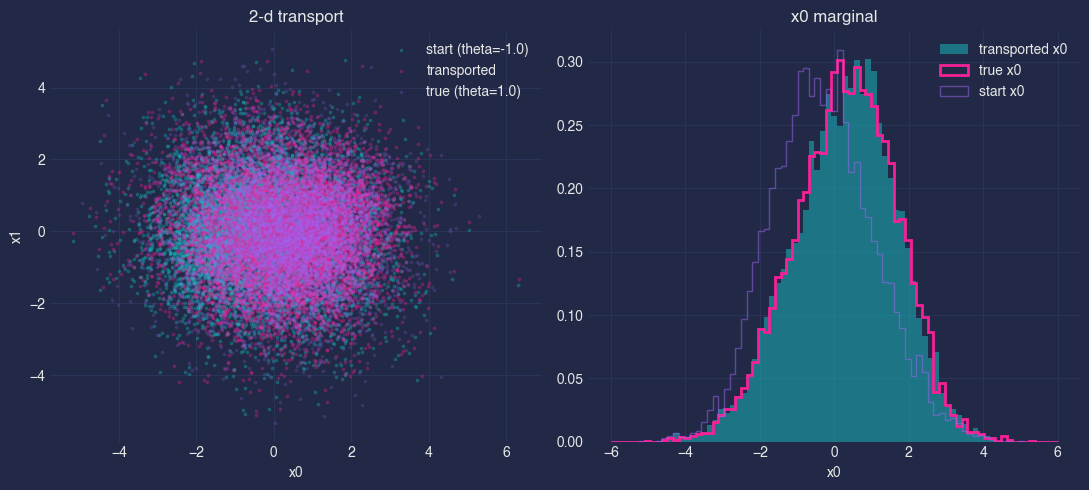

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
ax = axes[0]
ax.scatter(x0[:, 0], x0[:, 1], s=3, alpha=0.25, label=f'start (theta={theta_0})')
ax.scatter(x1[:, 0], x1[:, 1], s=3, alpha=0.25, label='transported')
ax.scatter(x1_true[:, 0], x1_true[:, 1], s=3, alpha=0.15, label=f'true (theta={theta_1})')
ax.set_xlabel('x0'); ax.set_ylabel('x1'); ax.legend(); ax.set_title('2-d transport')

ax = axes[1]
bins = torch.linspace(-6, 6, 80).numpy()
ax.hist(x1[:, 0].numpy(), bins=bins, density=True, alpha=0.5, label='transported x0')
ax.hist(x1_true[:, 0].numpy(), bins=bins, density=True, histtype='step', lw=2, label='true x0')
ax.hist(x0[:, 0].numpy(), bins=bins, density=True, histtype='step', lw=1, alpha=0.5, label='start x0')
ax.set_xlabel('x0'); ax.legend(); ax.set_title('x0 marginal')
plt.tight_layout(); plt.show()

A quick quantitative check on the transported marginals: a 1-d Kolmogorov–Smirnov
statistic between transported and true samples on each axis (smaller is better; the
start-vs-true row is the baseline we should beat).

In [42]:
def ks_1d(a, b):
    grid = torch.cat([a, b]).sort().values
    ca = (a.unsqueeze(0) <= grid.unsqueeze(1)).float().mean(1)
    cb = (b.unsqueeze(0) <= grid.unsqueeze(1)).float().mean(1)
    return (ca - cb).abs().max().item()

for axis in range(d):
    ks_tr = ks_1d(x1[:, axis], x1_true[:, axis])
    ks_st = ks_1d(x0[:, axis], x1_true[:, axis])
    print(f'x{axis}: KS(transported, true)={ks_tr:.3f}   KS(start, true)={ks_st:.3f}')

x0: KS(transported, true)=0.009   KS(start, true)=0.203
x1: KS(transported, true)=0.015   KS(start, true)=0.015


## Energy distance

KS is per-axis; the **energy distance** is a single scalar that compares the full 2-d
distributions at once (zero iff equal).  We use the same estimator as `parameter-flow-2d`
and read it against two anchors: the *start-vs-true* baseline (what we must beat) and a
*true-vs-true* self-reference (the finite-sample floor we can't go below).

In [43]:
def energy_distance(a, b):
    md = lambda u, v: torch.cdist(u, v).mean()
    return 2 * md(a, b) - md(a, a) - md(b, b)

n = 2048
x1_true_b = sample_p_theta(torch.full((n, 1), theta_1), generator)  # independent true draw
ed_transported = energy_distance(x1[:n], x1_true[:n])
ed_start = energy_distance(x0[:n], x1_true[:n])
ed_floor = energy_distance(x1_true[:n], x1_true_b)
print(f'energy distance  transported-vs-true : {ed_transported.item():.3e}')
print(f'                 start-vs-true        : {ed_start.item():.3e}  (baseline to beat)')
print(f'                 true-vs-true (floor) : {ed_floor.item():.3e}  (sampling floor)')

energy distance  transported-vs-true : 1.724e-03
                 start-vs-true        : 1.612e-01  (baseline to beat)
                 true-vs-true (floor) : 1.770e-03  (sampling floor)


## Round-trip reversibility

A self-consistency check that needs no reference samples: bind the **reverse** path
$\theta_1\to\theta_0$ and transport the just-moved $x_1$ back.  The flow's velocity is a
fixed field, so $x_1 \to x_0$ should land back on the start (up to RK4 integration error).

round-trip RMS displacement: 5.570e-08  (0.00% of data scale)


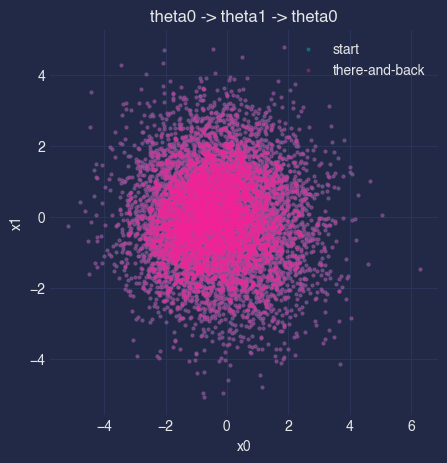

In [44]:
reverse = ParameterFlow(field, RK4(steps=64))(
    LinearParameterPath(torch.tensor([theta_1]), torch.tensor([theta_0]))
)
with torch.no_grad():
    x0_roundtrip = reverse.transport(x1)

displacement = (x0_roundtrip - x0).pow(2).sum(-1).sqrt()
scale = x0.std(0).mean().item()
print(f'round-trip RMS displacement: {displacement.mean().item():.3e}  '
      f'({100 * displacement.mean().item() / scale:.2f}% of data scale)')

plt.figure(figsize=(5, 5))
plt.scatter(x0[:, 0], x0[:, 1], s=4, alpha=0.3, label='start')
plt.scatter(x0_roundtrip[:, 0], x0_roundtrip[:, 1], s=4, alpha=0.3, label='there-and-back')
plt.xlabel('x0'); plt.ylabel('x1'); plt.legend()
plt.title('theta0 -> theta1 -> theta0'); plt.show()

## `score_supply` inverts the PDE

$$\partial_\theta \log\hat p_\theta(x) = -\Delta_x\phi - \nabla_x\phi\cdot\nabla_x\log p_\theta(x)$$

should reproduce the autograd joint-score oracle at a held-out $\theta$.  The spatial score
is a required input here (the recovery is the PDE solved for $\partial_\theta\log p$).

score_supply RMS error: 3.019e-03


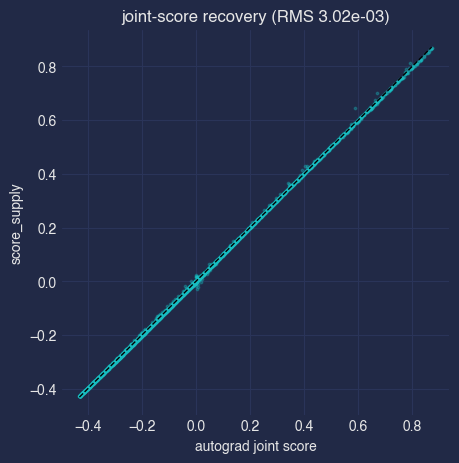

In [45]:
theta_eval = torch.full((4096, 1), 0.5)
x_eval = sample_p_theta(theta_eval, generator)
supplied = process.score_supply(x_eval, theta_eval, spatial_score=spatial)
target = joint(x_eval, theta_eval)

rms = (supplied - target).pow(2).mean().sqrt().item()
print(f'score_supply RMS error: {rms:.3e}')

plt.figure(figsize=(5, 5))
plt.scatter(target.squeeze(-1), supplied.detach().squeeze(-1), s=3, alpha=0.3)
lims = [target.min().item(), target.max().item()]
plt.plot(lims, lims, 'k--', lw=1)
plt.xlabel('autograd joint score'); plt.ylabel('score_supply')
plt.title(f'joint-score recovery (RMS {rms:.2e})'); plt.show()

## Dropping the oracle: recover the joint score with CTSM

So far the joint score $\partial_\theta\log p_\theta$ was handed to us by autograd on the
*known* mixture density.  Can we recover it from **samples alone**?  Conditional Time-Score
Matching (CTSM) trains a network $s_\phi(x, s)\approx\tfrac{d}{ds}\log p_{\theta(s)}(x)$
along a single `LinearParameterPath`, then `CTSMJointScore` undoes the chain rule
($\partial_\theta\log p = \tfrac{d}{ds}\log p / \dot\theta$) to give the joint score.
Because it inverts $\theta\to s$ on one segment, a CTSM score is **path-locked** — only
valid on the path it trained on (here $\theta_0\to\theta_1 = -1\to 1$).

The trick that makes this oracle-free: our simulator emits the **latent** signal/background
label, and the *latent* time score

$$\dot\theta\,\bigl[\mathbb{1}_\mathrm{sig}\,\Sigma_\mathrm{sig}^{-1}(x-\mu_\mathrm{sig}(\theta))\bigr]_{\mathrm{param\_dim}}$$

(background contributes nothing — it does not move with $\theta$) has the marginal time
score as its conditional mean.  Regressing on it with `time_score_matching_loss` needs **no**
density evaluation — exactly the no-oracle route from `test_parameter_flow_no_oracle`.

In [46]:
from torch import nn
from nami.components import SinusoidalTimeEmbedding
from nami.losses.score_matching import time_score_matching_loss
from nami.scores import CTSMJointScore

sig_cov_inv = torch.linalg.inv(toy.sig_cov)
l_sig = torch.linalg.cholesky(toy.sig_cov)
l_bkg = torch.linalg.cholesky(toy.bkg_cov)


def sample_with_label(theta_col, generator):
    """Like sample_p_theta, but also return the latent is_sig label."""
    n = theta_col.shape[0]
    is_sig = torch.rand(n, generator=generator) < toy.sig_frac
    mu_sig = toy.sig_loc.expand(n, d).clone()
    mu_sig[:, pdim] = theta_col[:, 0]
    eps = torch.randn(n, d, generator=generator)
    xs = mu_sig + eps @ l_sig.T
    xb = toy.bkg_loc + eps @ l_bkg.T
    return torch.where(is_sig.unsqueeze(-1), xs, xb), is_sig


def latent_joint_score(x, is_sig, theta_col):
    """Per-sample latent score; E[.|x] is the marginal joint score. No density used."""
    mu_sig = toy.sig_loc.expand(x.shape[0], d).clone()
    mu_sig[:, pdim] = theta_col[:, 0]
    comp = ((x - mu_sig) @ sig_cov_inv.T)[:, pdim:pdim + 1]  # [Sig^-1 (x - mu)]_param_dim
    return is_sig.unsqueeze(-1).float() * comp

Train the time-score net along the transport path.  We reuse the package's
`SinusoidalTimeEmbedding` for the path coordinate $s$, matching the no-oracle test's net.

ctsm step 0: loss 1.394e+00
ctsm step 1000: loss 9.617e-01
ctsm step 2000: loss 1.004e+00
ctsm step 3000: loss 9.670e-01


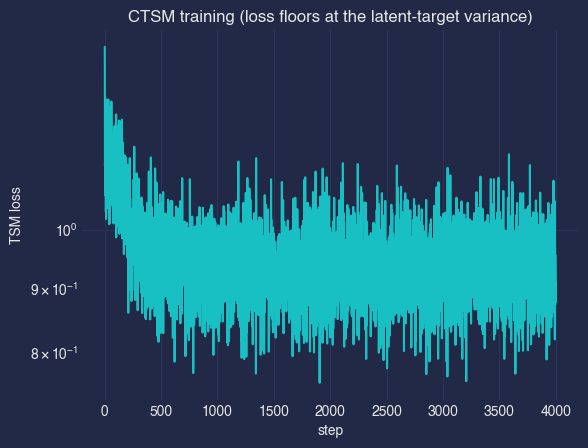

In [47]:
path = LinearParameterPath(torch.tensor([theta_0]), torch.tensor([theta_1]))
delta_theta = theta_1 - theta_0  # constant path tangent (linear path)

t_emb = SinusoidalTimeEmbedding(16, max_period=100.0)
ts_net = nn.Sequential(
    nn.Linear(d + 16, 128), nn.SiLU(), nn.Linear(128, 128), nn.SiLU(), nn.Linear(128, 1)
)


def ts_wrapped(x, s):
    feats = t_emb(s, leading_shape=x.shape[:-1], device=x.device, dtype=x.dtype)
    return ts_net(torch.cat([x, feats], dim=-1))


opt = torch.optim.Adam(ts_net.parameters(), lr=1e-3)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=4000, eta_min=1e-5)
ctsm_losses = []
for step in range(4000):
    s = torch.rand(2048, generator=generator)
    theta_s = path.theta(s)
    x, is_sig = sample_with_label(theta_s, generator)
    target = delta_theta * latent_joint_score(x, is_sig, theta_s).squeeze(-1)
    loss = time_score_matching_loss(ts_wrapped, x=x, s=s, target=target)
    opt.zero_grad(); loss.backward(); opt.step(); sched.step()
    ctsm_losses.append(loss.item())
    if step % 1000 == 0:
        print(f'ctsm step {step}: loss {loss.item():.3e}')

joint_ctsm = CTSMJointScore(ts_wrapped, path)
plt.semilogy(ctsm_losses)
plt.xlabel('step'); plt.ylabel('TSM loss')
plt.title('CTSM training (loss floors at the latent-target variance)'); plt.show()

### Does CTSM recover the analytic joint score?

Compare `CTSMJointScore` against the autograd oracle at several $\theta$ **on the path**.
RMS should sit near the no-oracle test's bar ($<0.1$).

theta=-0.6: CTSM-joint vs analytic RMS 1.082e-02
theta=+0.0: CTSM-joint vs analytic RMS 1.131e-02
theta=+0.6: CTSM-joint vs analytic RMS 1.179e-02


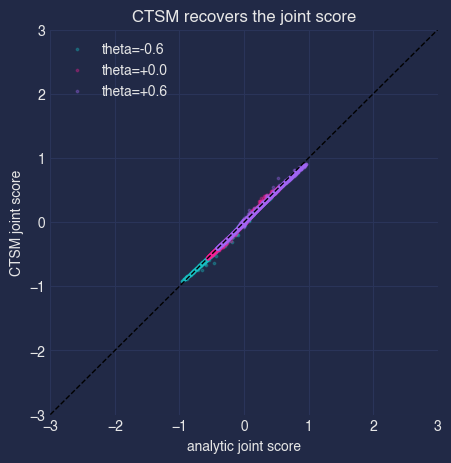

In [48]:
fig, ax = plt.subplots(figsize=(5, 5))
for tval in (-0.6, 0.0, 0.6):
    theta = torch.full((4096, 1), tval)
    x, _ = sample_with_label(theta, generator)
    with torch.no_grad():
        ctsm = joint_ctsm(x, theta)
    oracle = joint(x, theta)
    rms = (ctsm - oracle).pow(2).mean().sqrt().item()
    print(f'theta={tval:+.1f}: CTSM-joint vs analytic RMS {rms:.3e}')
    ax.scatter(oracle.squeeze(-1), ctsm.squeeze(-1), s=3, alpha=0.3, label=f'theta={tval:+.1f}')
lims = [-3, 3]
ax.plot(lims, lims, 'k--', lw=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('analytic joint score'); ax.set_ylabel('CTSM joint score')
ax.legend(); ax.set_title('CTSM recovers the joint score'); plt.show()

### Closing the loop: three independent routes agree

At a held-out $\theta$ on the path we now have **three** estimates of
$\partial_\theta\log p_\theta(x)$ that never shared information:

1. **analytic** — autograd on the known density;
2. **CTSM** — learned from samples + latent labels, no density;
3. **`score_supply`** — recovered from the trained potential $\phi$ via the PDE.

If the whole construction is consistent, all three should overlay.

CTSM      vs analytic : RMS 1.129e-02
score_supply vs analytic : RMS 3.209e-03
score_supply vs CTSM     : RMS 1.043e-02  (both oracle-free vs each other)


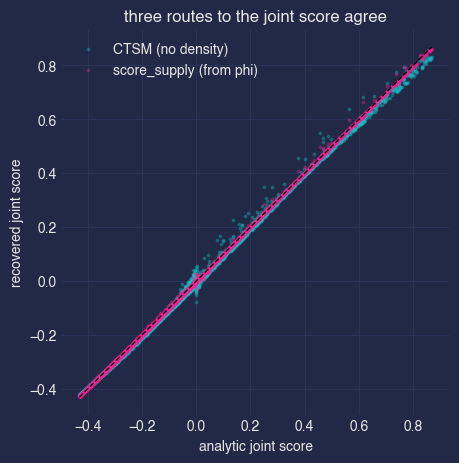

In [49]:
theta_eval = torch.full((4096, 1), 0.5)  # on the path [-1, 1]
x_eval = sample_p_theta(theta_eval, generator)

analytic_j = joint(x_eval, theta_eval)
with torch.no_grad():
    ctsm_j = joint_ctsm(x_eval, theta_eval)
supplied_j = process.score_supply(x_eval, theta_eval, spatial_score=spatial)

rms_ctsm = (ctsm_j - analytic_j).pow(2).mean().sqrt().item()
rms_supplied = (supplied_j.detach() - analytic_j).pow(2).mean().sqrt().item()
rms_pair = (supplied_j.detach() - ctsm_j).pow(2).mean().sqrt().item()
print(f'CTSM      vs analytic : RMS {rms_ctsm:.3e}')
print(f'score_supply vs analytic : RMS {rms_supplied:.3e}')
print(f'score_supply vs CTSM     : RMS {rms_pair:.3e}  (both oracle-free vs each other)')

plt.figure(figsize=(5, 5))
plt.scatter(analytic_j.squeeze(-1), ctsm_j.squeeze(-1), s=3, alpha=0.3, label='CTSM (no density)')
plt.scatter(analytic_j.squeeze(-1), supplied_j.detach().squeeze(-1), s=3, alpha=0.3, label='score_supply (from phi)')
lims = [analytic_j.min().item(), analytic_j.max().item()]
plt.plot(lims, lims, 'k--', lw=1)
plt.xlabel('analytic joint score'); plt.ylabel('recovered joint score')
plt.legend(); plt.title('three routes to the joint score agree'); plt.show()

## Closing the loop: train $\phi$ with the learned joint score

The three routes *agree*, but we trained $\phi$ with the **analytic** joint score.  The real
test of the mining-gold route is to **drop the oracle entirely**: train a fresh potential
using `joint_ctsm` (learned from samples + latent labels) as the joint score, then re-run the
two-sample transport test.  If the learned score is good enough, the no-oracle field should
transport just as well as the oracle one.

Because `CTSMJointScore` is path-locked we sample the training $\theta$ **on the segment**
($\theta=\theta(s),\,s\sim\mathcal{U}[0,1]$).  The spatial score stays analytic here to
isolate the joint-score swap; replacing it with a `DSMSpatialScore` (see
`test_parameter_flow_no_oracle`) is the natural next step to a fully oracle-free loop.

energy distance  oracle phi (earlier) : 1.724e-03
                 NO-ORACLE phi (CTSM) : 1.844e-03
                 true-vs-true floor   : 1.770e-03
transported mean x0  no-oracle +0.279  vs true +0.292


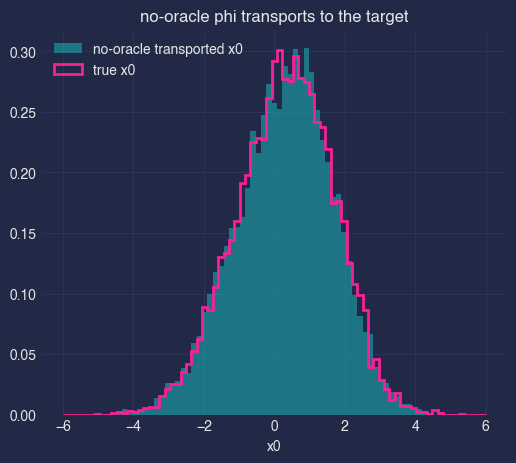

In [50]:
def train_phi(joint_src, seed):
    torch.manual_seed(seed)
    fld = ScalarPotentialField(d, theta_dim=1, hidden=64, layers=3)
    o = torch.optim.Adam(fld.parameters(), lr=1e-3)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(o, T_max=3000)
    for _ in range(3000):
        s = torch.rand(512, generator=generator)
        theta = path.theta(s)  # on-segment: required by the path-locked CTSM score
        x = sample_p_theta(theta, generator)
        loss = parameter_flow_loss(fld, x=x, theta=theta, joint_score=joint_src, spatial_score=spatial)
        o.zero_grad(); loss.backward(); o.step(); sch.step()
    return fld

field_no_oracle = train_phi(joint_ctsm, seed=11)  # joint score learned from samples

proc_no = ParameterFlow(field_no_oracle, RK4(steps=64))(path)
with torch.no_grad():
    x1_no = proc_no.transport(x0)

ed_no = energy_distance(x1_no[:n], x1_true[:n])
print(f'energy distance  oracle phi (earlier) : {ed_transported.item():.3e}')
print(f'                 NO-ORACLE phi (CTSM) : {ed_no.item():.3e}')
print(f'                 true-vs-true floor   : {ed_floor.item():.3e}')
print(f'transported mean x0  no-oracle {x1_no[:, 0].mean().item():+.3f}  vs true {x1_true[:, 0].mean().item():+.3f}')

fig, ax = plt.subplots(figsize=(6, 5))
ax.hist(x1_no[:, 0].numpy(), bins=torch.linspace(-6, 6, 80).numpy(), density=True, alpha=0.5, label='no-oracle transported x0')
ax.hist(x1_true[:, 0].numpy(), bins=torch.linspace(-6, 6, 80).numpy(), density=True, histtype='step', lw=2, label='true x0')
ax.set_xlabel('x0'); ax.legend(); ax.set_title('no-oracle phi transports to the target'); plt.show()

## The fully latent-free route: genuine `ctsm_loss`

The mining-gold target above still used the **latent** signal/background label.  Can we drop
*that* too?  `ctsm_loss` (Yu et al. 2025) trains a time score from **samples alone** by the
denoising trick along a Gaussian corruption path $x_t=\alpha_t z+\sigma_t\varepsilon$ — no
labels, no density.  The catch (documented on the loss): it learns the time score along the
**noise** path, so it only recovers a *parameter* score when the parameter path **coincides**
with a Gaussian conditional path.

There is one family where it does: the **mean-ray, identity-covariance Gaussian**
$p_\theta=\mathcal{N}((\theta,0), I)$.  With data $z\sim\mathcal{N}((m,0),I)$ and a VP
schedule ($\alpha_t^2+\sigma_t^2=1$), the marginal is
$p_t=\mathcal{N}((\alpha_t m, 0),\,\alpha_t^2 I+\sigma_t^2 I)=\mathcal{N}((\alpha_t m,0), I)$
— a pure mean-shift with $\theta(t)=\alpha_t m$.  So the VP noise path *is* the parameter path,
and we can read $\partial_\theta\log p$ off the time-score net via the chain rule
$\partial_\theta\log p=\tfrac{d}{dt}\log p / (\dot\alpha_t\,m)$.

ctsm_loss step 0: loss 1.023e+00
ctsm_loss step 1250: loss 6.358e-01
ctsm_loss step 2500: loss 6.586e-01
ctsm_loss step 3750: loss 6.555e-01


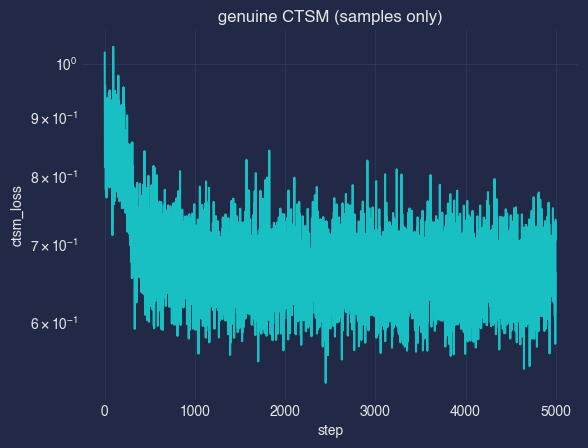

In [51]:
from nami.losses.score_matching import ctsm_loss
from nami.schedules.vp import VPSchedule

M = 1.5  # data mean magnitude along dim 0
schedule = VPSchedule(beta_min=0.1, beta_max=20.0)
alpha_dot = lambda t: -0.5 * (schedule.beta_min + t * (schedule.beta_max - schedule.beta_min)) * schedule.alpha(t)


def gauss_data(nb):
    z = torch.randn(nb, 2, generator=generator); z[:, 0] += M
    return z


g_emb = SinusoidalTimeEmbedding(16, max_period=100.0)
g_net = nn.Sequential(nn.Linear(2 + 16, 128), nn.SiLU(), nn.Linear(128, 128), nn.SiLU(), nn.Linear(128, 1))


def g_wrapped(x, t):
    feats = g_emb(t, leading_shape=x.shape[:-1], device=x.device, dtype=x.dtype)
    return g_net(torch.cat([x, feats], dim=-1))


opt = torch.optim.Adam(g_net.parameters(), lr=1e-3)
sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=5000, eta_min=1e-5)
ctsm_losses = []
for step in range(5000):
    loss = ctsm_loss(g_wrapped, x_data=gauss_data(2048), schedule=schedule)
    opt.zero_grad(); loss.backward(); opt.step(); sch.step()
    ctsm_losses.append(loss.item())
    if step % 1250 == 0:
        print(f'ctsm_loss step {step}: loss {loss.item():.3e}')
plt.semilogy(ctsm_losses); plt.xlabel('step'); plt.ylabel('ctsm_loss'); plt.title('genuine CTSM (samples only)'); plt.show()

Recover $\partial_\theta\log p_\theta=(x_0-\theta)$ from the samples-only net and compare to truth.

theta=0.944: latent-free param-score RMS 4.282e-02  (truth std 0.99)
theta=0.422: latent-free param-score RMS 6.078e-02  (truth std 1.00)
theta=0.127: latent-free param-score RMS 2.844e-02  (truth std 1.01)


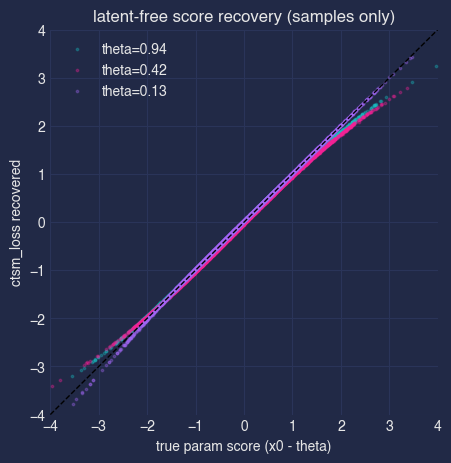

In [52]:
fig, ax = plt.subplots(figsize=(5, 5))
for tv in (0.3, 0.5, 0.7):
    t = torch.full((4096,), tv)
    a = schedule.alpha(t)
    theta = a * M  # the parameter this noise level corresponds to
    x = torch.randn(4096, 2, generator=generator); x[:, 0] += theta
    with torch.no_grad():
        param_score = g_wrapped(x, t).squeeze(-1) / (alpha_dot(t) * M)  # chain-rule unwrap
    truth = x[:, 0] - theta
    rms = (param_score - truth).pow(2).mean().sqrt().item()
    print(f'theta={theta[0].item():.3f}: latent-free param-score RMS {rms:.3e}  (truth std {truth.std().item():.2f})')
    ax.scatter(truth, param_score, s=3, alpha=0.3, label=f'theta={theta[0].item():.2f}')
lims = [-4, 4]; ax.plot(lims, lims, 'k--', lw=1); ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('true param score (x0 - theta)'); ax.set_ylabel('ctsm_loss recovered')
ax.legend(); ax.set_title('latent-free score recovery (samples only)'); plt.show()

## Why `ctsm_loss` does **not** transfer to the mixture

The recovery above worked only because the VP noise path *coincides* with the parameter
family.  For the signal+background **mixture** it does not — and we can show this directly,
with no training: noise a batch to level $t$ and ask whether **any** family member
$p_\theta,\,\theta\in[-1,1]$ matches the VP marginal (energy distance).  For the Gaussian the
best match sits at the sampling floor; for the mixture it stays far above, and worsens with
$t$ — the noise path leaves the family.  That mismatch is exactly why the denoising score is
the wrong object for a mixture parameter path, and why the mining-gold route was needed.

In [ ]:
def vp_marginal(data, t):
    tt = torch.tensor(t)
    return schedule.alpha(tt) * data + schedule.sigma(tt) * torch.randn(data.shape, generator=generator)

m_data = gauss_data(4000)
mix_data = sample_p_theta(torch.full((4000, 1), theta_1), generator)
theta_scan = torch.linspace(-1.0, 1.0, 9)
print(f"{'t':>5} | {'GAUSS  ED(VP, matched family)':>30} | {'MIX  best ED over theta in [-1,1]':>34}")
for t in (0.3, 0.6):
    a = schedule.alpha(torch.tensor(t)).item()
    g_fam = torch.randn(4000, 2, generator=generator); g_fam[:, 0] += a * M
    ed_g = energy_distance(vp_marginal(m_data, t)[:2048], g_fam[:2048]).item()
    vp_mix = vp_marginal(mix_data, t)[:2048]
    ed_mix = min(energy_distance(vp_mix, sample_p_theta(torch.full((2048, 1), tv.item()), generator)).item() for tv in theta_scan)
    print(f'{t:>5} | {ed_g:>30.3e} | {ed_mix:>34.3e}')
print('\nGauss: VP path stays in the family (denoising score == parameter score).')

    t |  GAUSS  ED(VP, matched family) |  MIX  best ED over theta in [-1,1]
  0.3 |                      1.667e-03 |                          9.935e-03
  0.6 |                      1.598e-03 |                          3.071e-02

Gauss: VP path stays in the family (denoising score == parameter score).
Mix:   no family member matches the VP marginal -> ctsm_loss cannot recover the parameter score.
